# Predicting Utilization

- <span style="color:green">Code grundsätzlich fertig<span>
- <span style="color:red">X-Werte noch anpassen<span>

Our idea for the prediction business case is to use a neural network, as this model class is expected to provide the highest predictive power for complex and non-linear utilization patterns.


However, to justify the added model complexity, we first establish a benchmark using linear and polynomial regression models.

---

### Target Variable (see also in feature_engineering.ipynb)

The target variable is the **total occupied charging minutes per hour**. We can see that the maximum possible utilization per hour is 3120 minutes which are equivalent to 3120 minutes / 60 minutes = 52 stations.

---

### Performance Evaluation Criteria

To assess whether a model (Regression model or Neural Network) is suitable for operational and strategic decision-making by a charging hub operator, the model performance is evaluated
along three complementary dimensions.


#### 1. Operational Accuracy

How many charging minutes per hour does the model misestimate on average?
→ This determines whether short-term planning (e.g. load management) is feasible.

**Metric used:** Mean Absolute Error (MAE)

The MAE is measured in minutes per hour and directly quantifies the average absolute deviation between predicted and observed occupied charging minutes. Because of its intuitive interpretation in the original unit of the target variable, MAE is particularly suitable for operational decision-making.


#### 2. Relative Accuracy Compared to Site Capacity

How large are the prediction errors relative to the maximum possible utilization?
→ This allows interpretation in percentage terms and comparison across sites.

**Metric used:** MAE relative to maximum capacity

The MAE is expressed as a percentage of the maximum theoretical utilization
(52 charging stations × 60 minutes = 3120 minutes per hour). This normalization
provides a scale-independent measure of prediction accuracy and facilitates
comparability across different locations.


#### 3. Explanatory Power

Does the model capture the structural patterns of utilization over time?
→ Important to assess whether predictions are systematic or mostly noise.

**Metric used:** Coefficient of determination (R²)

The R² score indicates the proportion of variance in hourly utilization that is
explained by the model. High R² values suggest that the model successfully
captures systematic demand patterns rather than random fluctuations.


#### Training and Validation Monitoring

In addition to the evaluation metrics above, the Root Mean Squared Error (RMSE) is monitored during training and validation. RMSE is more sensitive to large errors than MAE and is therefore useful for
assessing convergence behavior, overfitting tendencies, and the stability of
the learning process across epochs.

---

Lets start with the models!

## Linear and Polynomial Regression Models

#### Import necessary important Libraries

In [1]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Read in the Data

In [2]:
site1 = pd.read_csv("FINAL1.csv")

In [3]:
site1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23594 entries, 0 to 23593
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                23594 non-null  int64  
 1   hour                      23594 non-null  int64  
 2   weekday                   23594 non-null  int64  
 3   dayOfMonth                23594 non-null  int64  
 4   month                     23594 non-null  int64  
 5   year                      23594 non-null  int64  
 6   total minutes of parking  23594 non-null  float64
 7   temperature               23594 non-null  float64
 8   cloud_cover               23594 non-null  float64
 9   pressure                  23594 non-null  float64
 10  windspeed                 23594 non-null  float64
 11  precipitation             23594 non-null  float64
 12  felt_temperature          23594 non-null  float64
 13  is_holiday                23594 non-null  int64  
 14  covid 

In [4]:
site1["total minutes of parking"].describe()

count    23594.000000
mean       467.155662
std        958.149017
min          0.000000
25%          0.000000
50%          0.000000
75%        214.683333
max       3120.000000
Name: total minutes of parking, dtype: float64

#### Create the target and the features

In [5]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

#### Split the data

In [6]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

- X_train, y_train → 60%: Training set

- X_val, y_val → 20%: Validation set

- X_test, y_test → 20%: Test set

#### Define potential hyperparameters

We define some combinations of hyperparameter we also used in the workshop

In [7]:
models = ["Linear", "Ridge", "Lasso"]
degrees = [1, 2, 3]
alphas = [0.01, 0.1, 1.0, 10.0]

#### Build the models

In [8]:
results = []

for model_name in models:
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_poly)
        X_val_scaled = scaler.transform(X_val_poly)

        if model_name == "Linear":
            reg = LinearRegression()
            reg.fit(X_train_scaled, y_train)
            y_val_pred = reg.predict(X_val_scaled)
            rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

            results.append({
                "model": model_name,
                "degree": degree,
                "alpha": None,
                "rmse": rmse
            })
        else:
            for alpha in alphas:
                if model_name == "Ridge":
                        reg = Ridge(alpha=alpha)
                else:
                        reg = Lasso(alpha=alpha, max_iter=10000)

                reg.fit(X_train_scaled, y_train)
                y_val_pred = reg.predict(X_val_scaled)
                rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

                results.append({
                    "model": model_name,
                     "degree": degree,
                    "alpha": alpha,
                    "rmse": rmse
                    })

#### Aggregate results

In [35]:
results_df = pd.DataFrame(results)

cv_summary = (
    results_df
    .groupby(["model", "degree", "alpha"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
    .sort_values("mean_rmse")
)

cv_summary.head()

,model,degree,alpha,mean_rmse
9,Lasso,3,0.10,573.244115
23,Ridge,3,10.00,576.192578
22,Ridge,3,1.00,577.362807
8,Lasso,3,0.01,579.739649
21,Ridge,3,0.10,582.898155


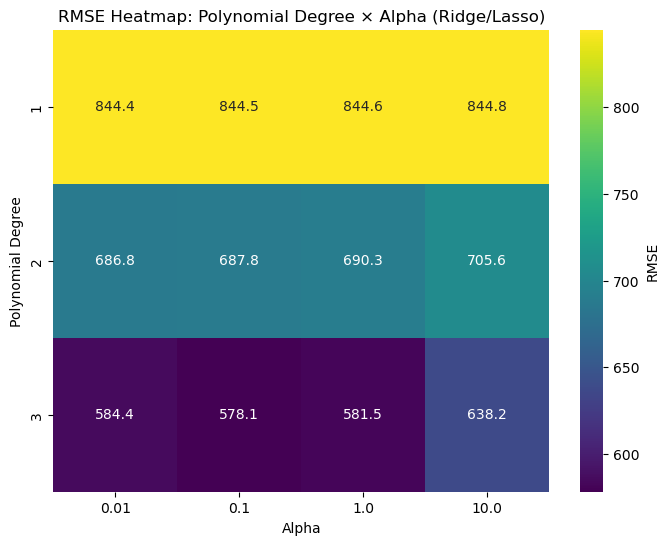

In [10]:
heatmap_data = results_df[results_df['alpha'].notna()]

pivot_table = heatmap_data.pivot_table(
    index='degree',
    columns='alpha',
    values='rmse',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="viridis", cbar_kws={"label": "RMSE"})
plt.title("RMSE Heatmap: Polynomial Degree × Alpha (Ridge/Lasso)")
plt.ylabel("Polynomial Degree")
plt.xlabel("Alpha")
plt.show()

In [11]:
best = cv_summary.iloc[0]
print("Best benchmark configuration:")
print(best)

Best benchmark configuration:
model             Lasso
degree                3
alpha               0.1
mean_rmse    573.244115
std_rmse            NaN
Name: 9, dtype: object


#### Train best regression model and evaluate the performance on the est set

In [34]:
poly = PolynomialFeatures(degree=int(best["degree"]), include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

norm = StandardScaler()
X_train_scaled = norm.fit_transform(X_train_poly)
X_test_scaled = norm.transform(X_test_poly)

if best["model"] == "Linear":
    final_reg = LinearRegression()
elif best["model"] == "Ridge":
    final_reg = Ridge(alpha=best["alpha"])
else:
    final_reg = Lasso(alpha=best["alpha"], max_iter=10000)

final_reg.fit(X_train_scaled, y_train)
y_test_pred = final_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 415.7696932778456
MAE (in percentage): 13.325951707623258
R2: 0.6340084467720084
RMSE: 567.5742510618675


### Overall Performance of the Regression Models

The best regression model achieves a Mean Absolute Error (MAE) of **X** minutes per hour. This means that, on average, the model deviates from the observed hourly utilization by roughly **X** occupied charging minutes.

Given the maximum capacity of 3120 minutes per hour (52 charging stations × 60 minutes), the MAE corresponds to a relative prediction error of **X**.

The R² of **X** shows that the model explains only **X** of the observed variance in hourly utilization. This **low explanatory power** (value near 0) indicates that the model fails to capture systematic demand patterns and mainly reflects random noise.

In addition, the model achieves an RMSE of **X** minutes per hour. This indicates that the model frequently makes substantial prediction errors, and the predictions are highly unstable across different hours.

From an operational perspective, such an average error represents a significant portion of total site capacity, making this model unsuitable for utilization forecasting or decision support.

Let's stick to our initial thoughts and build up some Neural Networks to see if this works out better!


## Neural Network

### NN for Site 1

First we build up a NN for Site 1 with common hyperparameters, to see if a NN is better suitable for this task.

We have already defined the target variable and features for the regression models, and split the data into training, validation, and test sets.

We can still all of this to buid up our NN

In [13]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import Sequential # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout
from keras.regularizers import l2

%matplotlib inline

#### Scale the data

In [14]:
norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

#### Build the NN
We use a common neural network architecture from the lecture, but we also include the Keras L2 regularizer to reduce overfitting and improve the model’s generalization to new data.

For the output layer we use ReLu as activation function because the target variable is strictly non-negative by definition.

In [15]:
predictor = Sequential()

predictor.add(Dense(units=64,
                     activation='relu',
                     input_shape=(14,)))

predictor.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
predictor.add(Dropout(0.05))

predictor.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
predictor.add(Dropout(0.05))

predictor.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
predictor.add(Dropout(0.05))

predictor.add(Dense(1, activation='relu'))

predictor.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the NN

In [16]:
predictor.compile(loss='mse',
             optimizer="adam",
             metrics=["mae", "mse"])

#### Train the NN

In [17]:
history = predictor.fit(X_norm_train, y_train,
                            validation_data=(X_norm_val, y_val),
                            epochs=100,
                            batch_size=50)

Epoch 1/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 861234.5000 - mae: 584.8504 - mse: 861234.1875 - val_loss: 684132.0000 - val_mae: 546.1622 - val_mse: 684131.6250
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 612709.5000 - mae: 486.5481 - mse: 612709.1875 - val_loss: 475380.4062 - val_mae: 418.2838 - val_mse: 475379.8438
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 334803.8125 - mae: 324.7711 - mse: 334803.2188 - val_loss: 248409.5938 - val_mae: 268.9450 - val_mse: 248408.9062
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 221672.2344 - mae: 243.7871 - mse: 221671.4219 - val_loss: 179661.6094 - val_mae: 208.1991 - val_mse: 179660.9219
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 188381.2656 - mae: 214.9808 - mse: 188380.3906 - val_loss: 163981.0938 - val_mae: 194.0831 - val_mse: 163980.2812
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 175802.2969 - mae: 203.0976 - mse: 175801.4688 - val_loss:

#### Results of the NN

In [18]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,861234.500000,584.850403,861234.187500,684132.000000,546.162170,684131.625000
1,612709.500000,486.548096,612709.187500,475380.406250,418.283752,475379.843750
2,334803.812500,324.771118,334803.218750,248409.593750,268.945007,248408.906250
3,221672.234375,243.787109,221671.421875,179661.609375,208.199142,179660.921875
4,188381.265625,214.980804,188380.390625,163981.093750,194.083069,163980.281250
...,...,...,...,...,...,...
95,46371.742188,95.265724,46368.238281,55924.105469,94.800217,55920.558594
96,43714.636719,92.901253,43711.113281,48230.582031,89.528923,48227.015625
97,42560.707031,92.527977,42557.101562,64395.996094,105.206535,64392.394531
98,44518.042969,94.246124,44514.468750,53138.898438,91.672867,53135.269531


In [19]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,928.027040,827.122497
1,782.757426,689.477950
2,578.621827,498.406367
3,470.819946,423.864273
4,434.028099,404.944788
...,...,...
95,215.332855,236.475281
96,209.072029,219.606502
97,206.293726,253.756565
98,210.984523,230.510888


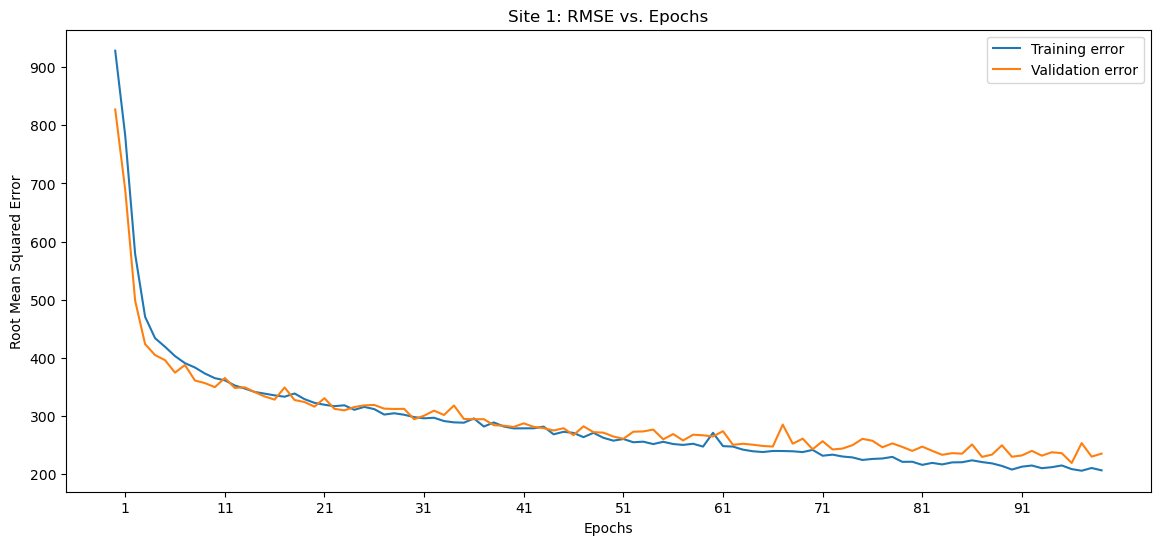

In [20]:
plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(1,101,10))
plt.legend()
plt.title("Site 1: RMSE vs. Epochs")

plt.show()

#### Evaluate Performance on Test Set regarding our performance criterions.

In [21]:
y_pred = predictor.predict(X_norm_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 94.07225521946135
MAE (in percentage): 3.015136385239146
R2: 0.9394407805618832
RMSE: 230.875201757413


### Overall Performance of the initial NN

We can now definitly see, that are results are way better than for our regression models!

The neural network developed for Site 1 achieves a Mean Absolute Error (MAE) of **X** minutes per hour. This indicates that, on average, the model deviates from the observed hourly utilization by approximately **X** occupied charging minutes.

Given the maximum capacity of 3120 minutes per hour (52 charging stations × 60 minutes), the MAE corresponds to a relative prediction error of **X**.

The R² of **X** shows that the model explains over **X** of the observed variance in hourly utilization. This high explanatory power (Value near 1) indicates that the neural network captures systematic demand patterns rather than merely fitting random fluctuations in the data.

In addition, the model achieves a RMSE of **X** minutes per hour.
Since RMSE penalizes larger deviations more strongly than MAE, this metric provides insight into the
presence and impact of occasional large prediction errors. The relatively low RMSE value in relation to the MAE indicates stable model behavior and suggests that large misestimations are infrequent.

From an operational perspective, an average error of approximately **X** of the total site capacity
is considered acceptable for utilization forecasting and decision support. The combination of low
absolute and relative errors, together with high R² values, confirms that the model provides both
accurate and structurally meaningful predictions.

Given these strong initial results, the neural network approach is deemed more suitable for the given
prediction task. Consequently, the subsequent analysis focuses on systematic hyperparameter tuning
to further improve model performance and robustness.

### Finding the best hyperparamters

To find the best hyperperameters we use Random Search strategy. Random Search has been shown to be
more efficient than grid search in high-dimensional hyperparameter spaces, as it explores a broader range of configurations while remaining computationally tractable.

Because the results for Site 1 and 2 were very similar and our prediction use-case ist only for Site **X** we use the data from this site.

#### Import futher librarys

In [23]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from scipy.stats import uniform, randint
from sklearn.model_selection import ParameterSampler

#### Build up the NN as a function

We use the same components as for the NNs above, but define a function for building up the NNs

In [24]:
def build_NN(
    num_hidden_layers=2,
    units_hidden=32,
    dropout_rate=0.2,
    regularization=0.001
):
    predictor = Sequential()
    predictor.add(Dense(units=units_hidden,
                     activation='relu',
                     input_shape=(14,)))

    for _ in range(num_hidden_layers):
        predictor.add(Dense(
            units_hidden,
            activation="relu",
            kernel_regularizer=l2(regularization)
        ))
        predictor.add(Dropout(dropout_rate))

    predictor.add(Dense(1, activation="relu"))

    predictor.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae", "mse"]
    )

    return predictor

#### Define randomly sampled hyperparameter

The following hyperparameters are randomly sampled to explore a wide range of possible
network configurations while remaining computationally feasible.

In [25]:
distributions = {
    "num_hidden_layers": randint(2, 6),
    "units_hidden": randint(32, 256),
    "dropout_rate": uniform(0.05, 0.35),
    "regularization": uniform(1e-5, 5e-3),
    "epochs": randint(50, 150),
    "batch_size": randint(16, 128)
}


param_list = list(ParameterSampler(
    distributions,
    n_iter=10,
    random_state=42
))

#### Random search function, finding the best hyperparameters

To improve the robustness of the hyperparameter selection, each randomly sampled
network configuration is evaluated using **5 different train/validation/test splits**.

This nested evaluation reduces the risk of selecting hyperparameters that perform well
only on a single data split and ensures that the chosen configuration generalizes
consistently across different temporal and structural data variations.

In [26]:
best_score = float("inf")
best_params = None
best_model = None

for params in param_list:
    print(f"Testing combination: {params}")
    val_losses = []

    for seed in range(5):
        X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=seed)

        scaler = StandardScaler()
        X_norm_train = scaler.fit_transform(X_train)
        X_norm_val = scaler.transform(X_val)

        model = build_NN(
            num_hidden_layers=params["num_hidden_layers"],
            units_hidden=params["units_hidden"],
            dropout_rate=params["dropout_rate"],
            regularization=params["regularization"]
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_norm_train,
            y_train,
            validation_data=(X_norm_val, y_val),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0,
            callbacks=[early_stopping]
        )

        val_losses.append(min(history.history["val_loss"]))

    mean_val_loss = np.mean(val_losses)

    if mean_val_loss < best_score:
        best_score = mean_val_loss
        best_params = params
        best_model = model

Testing combination: {'batch_size': 118, 'dropout_rate': np.float64(0.3287900454010815), 'epochs': 64, 'num_hidden_layers': 4, 'regularization': np.float64(0.0039084550013638465), 'units_hidden': 52}
Testing combination: {'batch_size': 118, 'dropout_rate': np.float64(0.2060414634987569), 'epochs': 136, 'num_hidden_layers': 4, 'regularization': np.float64(0.002306244459829336), 'units_hidden': 148}
Testing combination: {'batch_size': 115, 'dropout_rate': np.float64(0.10000338627267927), 'epochs': 52, 'num_hidden_layers': 3, 'regularization': np.float64(0.00029205789513550134), 'units_hidden': 119}
Testing combination: {'batch_size': 123, 'dropout_rate': np.float64(0.3784934481555125), 'epochs': 51, 'num_hidden_layers': 5, 'regularization': np.float64(0.004971057796456087), 'units_hidden': 192}
Testing combination: {'batch_size': 91, 'dropout_rate': np.float64(0.2640786061708983), 'epochs': 138, 'num_hidden_layers': 2, 'regularization': np.float64(0.002633873301291946), 'units_hidden': 2

#### Best Hyperparameters Found

In [27]:
print("Best parameters found:")
print(best_params)
print("Best validation loss:", best_score)

Best parameters found:
{'batch_size': 107, 'dropout_rate': np.float64(0.20405337280886043), 'epochs': 120, 'num_hidden_layers': 5, 'regularization': np.float64(0.002485884550556351), 'units_hidden': 206}
Best validation loss: 48751.03515625


### Finally: Build up the "best model" with the best hyperparamaters

In [28]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

final_model = build_NN(
            num_hidden_layers=best_params["num_hidden_layers"],
            units_hidden=best_params["units_hidden"],
            dropout_rate=best_params["dropout_rate"],
            regularization=best_params["regularization"]
        )

history = final_model.fit(
            X_norm_train,
            y_train,
            validation_data=(X_norm_val, y_val),
            epochs=best_params["epochs"],
            batch_size=best_params["batch_size"],
        )       

Epoch 1/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 775050.5000 - mae: 532.5440 - mse: 775047.7500 - val_loss: 455100.3125 - val_mae: 404.8611 - val_mse: 455097.4688
Epoch 2/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 281412.4375 - mae: 279.2974 - mse: 281409.4688 - val_loss: 173519.4531 - val_mae: 203.5076 - val_mse: 173516.3906
Epoch 3/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 188954.8594 - mae: 214.6395 - mse: 188951.6719 - val_loss: 162808.7344 - val_mae: 187.2640 - val_mse: 162805.5312
Epoch 4/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 160625.8750 - mae: 195.6941 - mse: 160622.5000 - val_loss: 123605.0078 - val_mae: 164.1849 - val_mse: 123601.6016
Epoch 5/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 145324.0469 - mae: 185.1123 - mse: 145320.5781 - val_loss: 120240.2422 - val_mae: 158.6415 - val_mse: 120236.6719
Epoch 6/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 136911.8594 - mae: 175.9965 - mse: 136908.2188 - val_loss:

#### Results of the best model

In [29]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,775050.500000,532.544006,775047.750000,455100.312500,404.861053,455097.468750
1,281412.437500,279.297363,281409.468750,173519.453125,203.507645,173516.390625
2,188954.859375,214.639542,188951.671875,162808.734375,187.264023,162805.531250
3,160625.875000,195.694077,160622.500000,123605.007812,164.184891,123601.601562
4,145324.046875,185.112320,145320.578125,120240.242188,158.641510,120236.671875
...,...,...,...,...,...,...
115,22092.025391,71.539482,22081.251953,29309.962891,73.023376,29299.123047
116,21313.367188,72.085915,21302.529297,29743.626953,66.086578,29732.722656
117,22612.494141,74.171951,22601.576172,27420.224609,66.198982,27409.273438
118,23401.882812,73.055374,23390.902344,24371.154297,64.074585,24360.152344


In [30]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,880.367963,674.609123
1,530.480413,416.552987
2,434.685716,403.491674
3,400.777370,351.570194
4,381.209363,346.751600
...,...,...
115,148.597618,171.169866
116,145.953860,172.431791
117,150.338206,165.557463
118,152.940846,156.077392


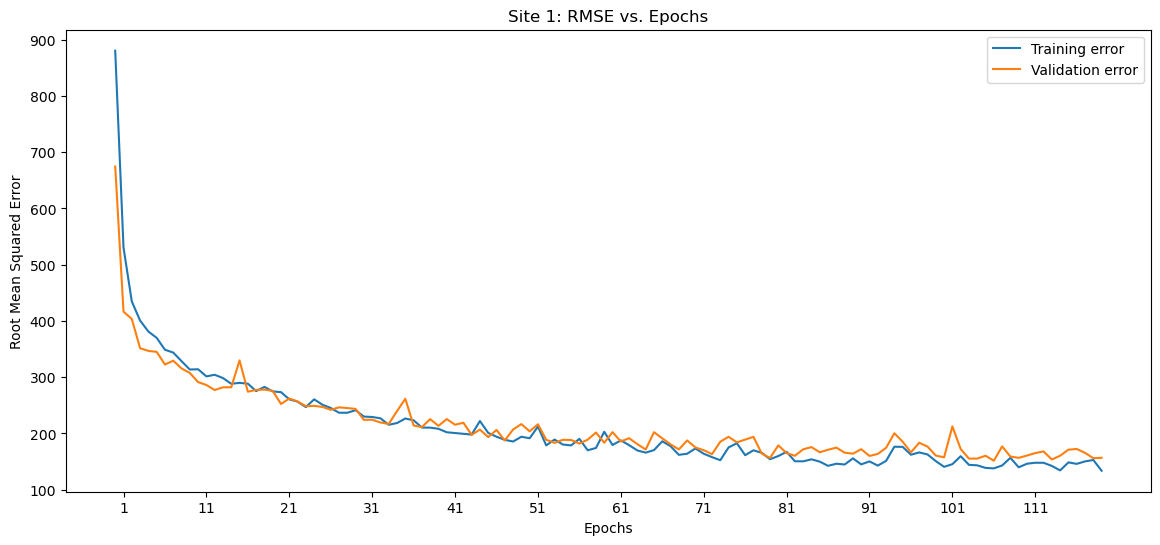

In [31]:
epochs = best_params["epochs"] + 1

plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(1, epochs, 10))
plt.legend()
plt.title("Site 1: RMSE vs. Epochs")

plt.show()

#### Evaluate the performance of the best model

In [32]:
y_pred = final_model.predict(X_norm_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [33]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 62.14527967440979
MAE (in percentage): 1.9918358870003139
R2: 0.9769697598829475
RMSE: 142.37586858538214


### Overall Performance of the NN with the best hyperparameters

We could further improve our initial Neural Network by finding the best (regarding our hardware) hyperparamters. 


The final results are the following (Jump to [here](#overall-performance-of-the-initial-nn) for the interpretation of the values):
- MAE: **X**
- MAE (in percentage): **X**
- R2: **X**